In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [8]:
import pandas as pd

df = pd.read_csv('/content/AQI-and-Lat-Long-of-Countries.csv')
df.head()  # Check the first few rows


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,lat,lng
0,51,1,36,0,51,44.7444,44.2031
1,41,1,5,1,41,-5.2900,-44.4900
2,41,1,5,1,41,-11.2958,-41.9869
3,66,1,39,2,66,37.1667,15.1833
4,34,1,34,0,20,53.0167,20.8833


In [13]:
df = df.dropna()
print(df)


       AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  \
0             51             1               36              0   
1             41             1                5              1   
2             41             1                5              1   
3             66             1               39              2   
4             34             1               34              0   
...          ...           ...              ...            ...   
16690         54             1               34              5   
16691         71             1               39              1   
16692         71             1               39              1   
16693         50             1               20              5   
16694         71             1               44              2   

       PM2.5 AQI Value      lat      lng  
0                   51  44.7444  44.2031  
1                   41  -5.2900 -44.4900  
2                   41 -11.2958 -41.9869  
3                   66  37.1667  15

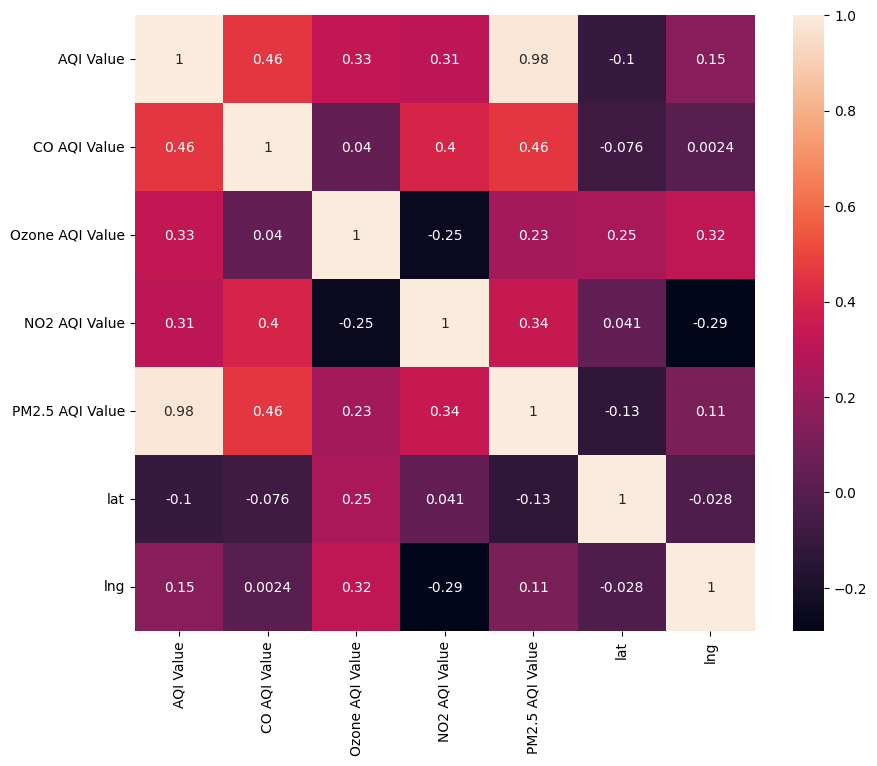

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()


In [15]:
df.columns


Index(['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value',
       'PM2.5 AQI Value', 'lat', 'lng'],
      dtype='object')

In [16]:
df.isnull().sum()


,0
AQI Value,0
CO AQI Value,0
Ozone AQI Value,0
NO2 AQI Value,0
PM2.5 AQI Value,0
lat,0
lng,0


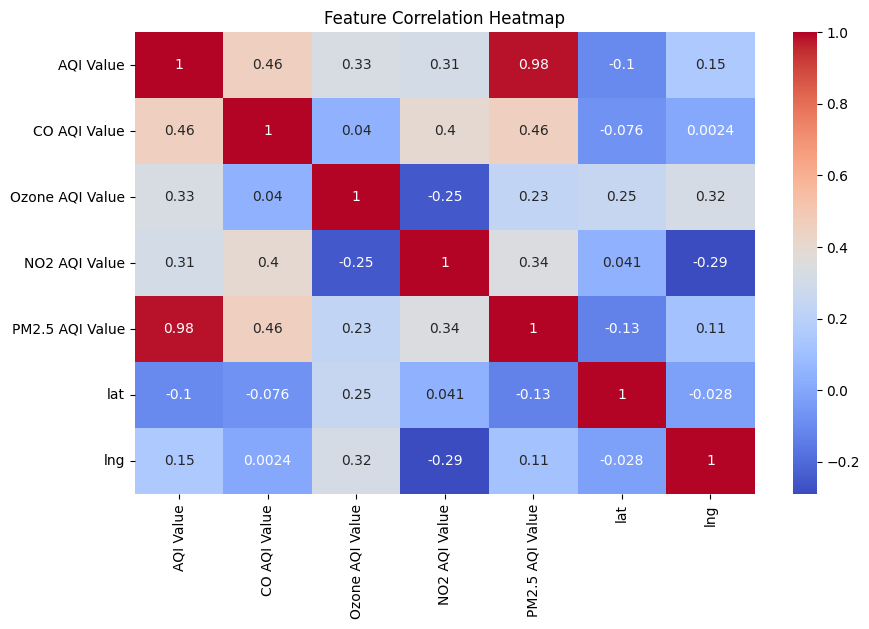

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [18]:
from sklearn.model_selection import train_test_split


X = df.drop("AQI Value", axis=1)
y = df["AQI Value"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Absolute Error: 4.126360949132347
Mean Squared Error: 41.797808105382074
R2 Score: 0.9747980672314599


In [21]:
import joblib

joblib.dump(model, 'AQI_model.pkl')

from google.colab import files
files.download('AQI_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:

sample = [[1, 14, 11, 54, 26.8941, -82.0513]]

predicted_aqi = model.predict(sample)
print("Predicted AQI:", predicted_aqi[0])


Predicted AQI: 53.91665411428693


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
import pandas as pd


sample = pd.DataFrame([{
    "CO AQI Value": 1,
    "Ozone AQI Value": 14,
    "NO2 AQI Value": 11,
    "PM2.5 AQI Value": 54,
    "lat": 26.8941,
    "lng": -82.0513
}])

predicted_aqi = model.predict(sample)
print("Predicted AQI:", predicted_aqi[0])


Predicted AQI: 53.91665411428693


In [24]:
import pandas as pd


sample = pd.DataFrame([{
    "CO AQI Value": 1,
    "Ozone AQI Value": 36,
    "NO2 AQI Value": 0,
    "PM2.5 AQI Value": 51,
    "lat": 44.7444,
    "lng": 44.2031
}])

predicted_aqi = model.predict(sample)
print("Predicted AQI:", predicted_aqi[0])

Predicted AQI: 55.30071736862812
